# Applied Multi product model 
This notebook contains the code that applies the multi product model to indian farmer survey:
[Link to survey](https://www-sciencedirect-com.vu-nl.idm.oclc.org/science/article/pii/S2352340922008319)

## Structure
The data will first be prepared into standard P and Q pairs for each crop type. Then both the LSV (numerical) and Variance (analytical) model will be implemented. Then the results are compared. Note that any symmetrical distribution, the LSV solution will be equal to the variance model

In [2]:
# Run once. Comment out if cvxpy is already installed in your environment.
%pip install cvxpy numpy pandas matplotlib tqdm -q

Note: you may need to restart the kernel to use updated packages.


error: externally-managed-environment

× This environment is externally managed
╰─> This Python installation is managed by uv and should not be modified.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [3]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from tqdm.auto import tqdm

np.random.seed(0)

C:\Users\lbr476\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
farmer_data = pd.read_csv('crop_yield.csv', low_memory=False)

#### Filter data ####

farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)

# Filter out rows with invalid or missing time values
farmer_data = farmer_data.dropna(subset=['time'])

farmer_data = farmer_data[(farmer_data['M-q706_cropSP'] < 10000) & (farmer_data['M-q706_cropSP'] > 0)].copy()  # Remove outliers
farmer_data = farmer_data[farmer_data['C-q306_cropLarestAreaAcre'] > 0]

farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)

# Filter out rows with invalid or missing time values
farmer_data = farmer_data.dropna(subset=['time'])



<cell>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)


In [4]:
# Convert yield per hectare to quintale per hectare
farmer_data['hectare_yield'] = farmer_data['L-tonPerHectare']
rupee_to_euro = 0.0091 # Exchange rate # 04-08-2026
farmer_data['euro_spot_price'] = farmer_data['M-q706_cropSP'] * rupee_to_euro * 10 # Convert to ton and then to euros

farmer_data["crop"] = farmer_data["D-q409_varType"]

crop_names = ["Improved", "Hybrid", "Local"]

full_data = []

# Helper: get neighbors by hierarchical location
def get_neighbors_with_time(source_row, target_df, k=3):
    levels = [
        "A-q105_village",
        "A-q104_subDistrict",
        "A-q103_district",
        "A-q102_state",
    ]

    for level in levels:
        matches = target_df[
            (target_df[level] == source_row[level]) &
            (target_df["time"].dt.to_period("M") ==
             source_row["time"].to_period("M"))
        ]
        if not matches.empty:
            # Return the k matches whose yield is closest to the source farmer's own yield
            yield_gap = (matches["hectare_yield"] - source_row["hectare_yield"]).abs()
            return matches.loc[yield_gap.nsmallest(k).index]

    # Fallback: closest in time
    target_df = target_df.copy()
    target_df["timediff"] = (target_df["time"] - source_row["time"]).abs()
    return target_df.nsmallest(k, "timediff")

total_rows = len(farmer_data)

for _, row in tqdm(
    farmer_data.iterrows(),
    total=total_rows,
    desc="Processing farmers",
    unit="farmer"
):

    crop = row["crop"]

    # Initialize dictionaries
    yield_vector = {c: np.nan for c in crop_names}
    price_vector = {c: np.nan for c in crop_names}

    # Observed crop
    yield_vector[crop] = row["hectare_yield"]
    price_vector[crop] = row["euro_spot_price"]

    # Estimate missing crops using neighbors
    for other_crop in [c for c in crop_names if c != crop]:

        target_df = farmer_data[farmer_data["crop"] == other_crop]
        nn = get_neighbors_with_time(row, target_df)

        if not nn.empty:
            yield_vector[other_crop] = nn["hectare_yield"].mean()
            price_vector[other_crop] = nn["euro_spot_price"].mean()

    # Store [Q_improved, Q_hybrid, Q_local, P_improved, P_hybrid, P_local]
    full_data.append(
        [yield_vector[c] for c in crop_names] +
        [price_vector[c] for c in crop_names]
    )


# Convert to array and remove incomplete rows
data_matrix = np.array(full_data, dtype=float)
data_matrix = data_matrix[~np.isnan(data_matrix).any(axis=1)]

print(f"Data matrix shape: {data_matrix.shape}")

Processing farmers:   0%|          | 0/7926 [00:00<?, ?farmer/s]

Processing farmers:   0%|          | 1/7926 [00:00<18:47,  7.03farmer/s]

Processing farmers:   0%|          | 3/7926 [00:00<12:05, 10.91farmer/s]

Processing farmers:   0%|          | 6/7926 [00:00<08:43, 15.14farmer/s]

Processing farmers:   0%|          | 9/7926 [00:00<06:52, 19.17farmer/s]

...

Processing farmers: 100%|█████████▉| 7922/7926 [07:37<00:00, 16.74farmer/s]

Processing farmers: 100%|█████████▉| 7924/7926 [07:37<00:00, 15.94farmer/s]

Processing farmers: 100%|██████████| 7926/7926 [07:37<00:00, 15.81farmer/s]

Processing farmers: 100%|██████████| 7926/7926 [07:37<00:00, 17.31farmer/s]

Data matrix shape: (7926, 6)


In [5]:
columns = [
    "Q_Improved",
    "Q_Hybrid",
    "Q_Local",
    "P_Improved",
    "P_Hybrid",
    "P_Local"
]

data_df = pd.DataFrame(data_matrix, columns=columns)

print("Sample data matrix (first 5 rows):")
print(data_df.head(5))

Sample data matrix (first 5 rows):
   Q_Improved  Q_Hybrid   Q_Local  P_Improved  P_Hybrid  P_Local
0         6.5       2.5  4.863333      122.85     318.5    318.5
1         6.5       2.5  4.863333      122.85     318.5    318.5
2         6.5       2.5  4.863333      122.85     318.5    318.5
3         6.5       2.5  4.863333      122.85     318.5    318.5
4         6.5       2.5  3.545000      122.85     318.5    318.5


## Multi-product model

Extends the single-crop model to allocate land shares $b_i$ and forward-contracted
quantities $q_i$ jointly across $n$ crops. The chance constraint on fulfillability is
rewritten as the linear constraint $q_i \le r_i b_i$, where $r_i = F_{Q_i}^{-1}(1-a_i)$
is the $(1-a_i)$-quantile of the yield $Q_i$ for a chosen credibility level $a_i$.

Note: here $a_i$ denotes the *credibility level* of crop $i$ (a probability), which is
unrelated to the per-sample $a_j$ used in the single-product `CVPI_optimization`. To avoid
confusion, the per-sample, per-crop analogues below are named `A_mat` and `C_mat`.

In [6]:
### Multi-product CVPI optimization ###

def r_from_credibility(Q, a_i):
    """
    r_i = F_Qi^{-1}(1 - a_i): the (1 - a_i)-quantile of the yield distribution,
    estimated nonparametrically from the observed sample of Q_i.
    P(Q_i >= r_i) ~= a_i   <=>   P(Q_i <= r_i) ~= 1 - a_i
    """
    return np.quantile(Q, 1.0 - a_i)


def Wbar_multi(b, q, PQbar_vec, Pbar_vec, f_vec):
    """E[W] for the multi-product model (linear in b, q)."""
    return np.sum(b * PQbar_vec) - np.sum(q * (Pbar_vec - f_vec))


def LSV_multi(b, q, A_mat, C_mat):
    """
    Sample lower semi-variance of W for given (b, q):
        LSV(b,q) = mean( max( sum_i [ b_i*A_ij - q_i*C_ij ], 0 )^2 )
    where A_ij = PQbar_i - P_ij*Q_ij and C_ij = Pbar_i - P_ij are the
    per-sample, per-crop analogues of the single-product a_j, b_j.
    """
    shortfall = A_mat @ b - C_mat @ q
    return np.mean(np.maximum(shortfall, 0.0) ** 2)


def CVPI_optimization_multi(A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False):
    """
    Multi-product LSV-minimizing optimization:

        min_{b,q}  (1/N) sum_j u_j^2
        s.t.       u_j >= sum_i (b_i*A_ij - q_i*C_ij)   (epigraph of the shortfall)
                   u_j >= 0
                   sum_i b_i = 1
                   q_i <= r_i * b_i                      for all i
                   b_i, q_i >= 0                         for all i
                   E[W](b,q) = PQbar_vec @ b - q @ (Pbar_vec - f_vec) >= m

    A_mat, C_mat            : (N, n) arrays, column i corresponds to crop i
    PQbar_vec, Pbar_vec,
    f_vec, r_vec             : length-n arrays
    """
    A_mat     = np.asarray(A_mat, dtype=float)
    C_mat     = np.asarray(C_mat, dtype=float)
    PQbar_vec = np.asarray(PQbar_vec, dtype=float)
    Pbar_vec  = np.asarray(Pbar_vec, dtype=float)
    f_vec     = np.asarray(f_vec, dtype=float)
    r_vec     = np.asarray(r_vec, dtype=float)

    N_, n_ = A_mat.shape

    # --- 1. Scale so the QP stays well conditioned (same idea as the single-product model) ---
    scale = np.median(np.abs(A_mat[A_mat != 0])) if np.any(A_mat != 0) else 1.0
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0

    A_s     = A_mat / scale
    C_s     = C_mat / scale
    PQbar_s = PQbar_vec / scale
    Pbar_s  = Pbar_vec / scale
    f_s     = f_vec / scale
    m_s     = m / scale

    # --- 2. Decision variables ---
    b = cp.Variable(n_, nonneg=True)   # land share per crop
    q = cp.Variable(n_, nonneg=True)   # forward-contracted quantity per crop
    u = cp.Variable(N_, nonneg=True)   # epigraph of the shortfall

    constraints = [
        u >= A_s @ b - C_s @ q,
        cp.sum(b) == 1,
        q <= cp.multiply(r_vec, b),                             # r_i * b_i >= q_i
        PQbar_s @ b - q @ (Pbar_s - f_s) >= m_s,                 # E[W] >= m
    ]

    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed: {prob.status}")

    b_star = b.value
    q_star = q.value
    lsv_star = prob.value * scale ** 2
    Wbar_star = Wbar_multi(b_star, q_star, PQbar_vec, Pbar_vec, f_vec)

    if verbose:
        print(f"Solver status : {prob.status}")
        print(f"b*            : {np.round(b_star, 4)}")
        print(f"q*            : {np.round(q_star, 4)}")
        print(f"LSV(b*,q*)    : {lsv_star:.4f}")
        print(f"E[W](b*,q*)   : {Wbar_star:.2f}  (must be >= m = {m})")

    return b_star, q_star, lsv_star, Wbar_star


### Analytical (Variance) multi-product model

*Reserved for the closed-form / analytical variance-based multi-product optimization
(counterpart to `Variance_optimum` in the single-product model).*

In [7]:
### Analytical (Variance) multi-product optimization — active-set method ###
#
# Decision vector v = [b_1, ..., b_n, q_1, ..., q_n]: the first n entries are the
# land shares b_i, the last n entries are the forward-contract sizes q_i. Both
# W's expectation and its variance are linear/quadratic forms in this single
# stacked vector, so the whole model reduces to:
#     min_v  v^T Sigma v
#     s.t.   sum(b_i) = 1, b_i >= 0, q_i >= 0, r_i*b_i >= q_i, E_Y^T v >= m
# solved via an equality-constrained active-set search (KKT system solved in
# closed form at each iteration).

def _solve_kkt(Sigma_inv, C, c):
    """Closed-form solution of min v^T Sigma v s.t. C @ v = c."""
    lambda_ = -2.0 * np.linalg.inv(C @ Sigma_inv @ C.T) @ c
    v = (-0.5 * lambda_ @ C @ Sigma_inv).flatten()
    return v, lambda_


def _constraint_blocks(n_crops, active_r, active_n, r_vec):
    """R: rows enforcing r_i*b_i - q_i = 0 for i in active_r (credibility, tight).
       N: rows enforcing v_i = 0 for i in active_n (non-negativity, tight)."""
    R = np.zeros((len(active_r), 2 * n_crops))
    for row, i in enumerate(active_r):
        R[row, i] = -r_vec[i]
        R[row, n_crops + i] = 1.0

    N = np.zeros((len(active_n), 2 * n_crops))
    for row, i in enumerate(active_n):
        N[row, i] = -1.0

    return R, N


def _solve_for_active_set(E_Y, Sigma_inv, active_n, active_r, m, r_vec, verbose=False):
    """Equality-constrained QP for a fixed active set; adds E[W] = m only if
    the unconstrained-in-m solution already violates E[W] >= m."""
    n_crops = len(E_Y) // 2
    active_r, active_n = sorted(active_r), sorted(active_n)
    R, N = _constraint_blocks(n_crops, active_r, active_n, r_vec)
    beta = np.array([1.0] * n_crops + [0.0] * n_crops)

    C1 = np.vstack([R, N, beta])
    c1 = np.zeros(C1.shape[0]); c1[-1] = 1.0

    if np.linalg.matrix_rank(C1) != np.linalg.matrix_rank(np.hstack([C1, c1[:, None]])):
        if verbose:
            print("Infeasible: constraints cannot be satisfied (rank deficiency).")
        return None, None, None, None

    v, lambda_ = _solve_kkt(Sigma_inv, C1, c1)
    expected_value = v @ E_Y
    if expected_value > m:
        return v, expected_value, v @ np.linalg.inv(Sigma_inv) @ v, lambda_

    C2 = np.vstack([R, N, beta, E_Y])
    c2 = np.append(c1, m)
    if np.linalg.matrix_rank(C2) != np.linalg.matrix_rank(np.hstack([C2, c2[:, None]])):
        if verbose:
            print("Infeasible: constraints with E[W] = m cannot be satisfied (rank deficiency).")
        return None, None, None, None

    v, lambda_ = _solve_kkt(Sigma_inv, C2, c2)
    return v, v @ E_Y, v @ np.linalg.inv(Sigma_inv) @ v, lambda_


def Variance_optimization_multi(Sigma, E_Y, m, r_vec, verbose=False, max_iter=100):
    """
    Analytical counterpart to CVPI_optimization_multi: minimizes Var(W) = v^T Sigma v
    for v = [b_1..b_n, q_1..q_n], subject to sum(b_i)=1, b_i,q_i >= 0,
    r_i*b_i >= q_i, E[W] >= m. Returns (b_star, q_star, variance_star, expected_value_star).
    """
    n_crops = len(E_Y) // 2
    Sigma_inv = np.linalg.inv(Sigma)
    active_r, active_n = set(), set()

    for it in range(1, max_iter + 1):
        v, expected_value, variance, lambda_ = _solve_for_active_set(
            E_Y, Sigma_inv, active_n, active_r, m, r_vec, verbose
        )
        if v is None:
            raise RuntimeError(f"Infeasible: active sets r={active_r}, n={active_n} can't satisfy E[W] >= {m}.")

        # C-block order is [R (credibility) | N (non-negativity) | beta] -> slice lambda_ to match
        lambdas_r = lambda_[:len(active_r)]
        lambdas_n = lambda_[len(active_r):len(active_r) + len(active_n)]

        if verbose:
            print(f"Iter {it}: active credibility {sorted(active_r)}, active non-negativity {sorted(active_n)}")
            print(f"  v = {np.round(v, 4)}, E[W] = {expected_value:.4f}")

        # Find any constraint violated by the current (unconstrained-on-it) solution
        violations = [(v[i], i, "n") for i in range(2 * n_crops) if v[i] < -1e-10]
        violations += [
            (r_vec[j] * v[j] - v[n_crops + j], j, "r")
            for j in range(n_crops) if r_vec[j] * v[j] - v[n_crops + j] < -1e-10
        ]
        if violations:
            _, idx, kind = min(violations, key=lambda x: x[0])
            (active_n if kind == "n" else active_r).add(idx)
            continue

        # No violations left: drop any active constraint with a negative multiplier
        active_pairs = list(zip(sorted(active_r), lambdas_r, ["r"] * len(active_r)))
        active_pairs += list(zip(sorted(active_n), lambdas_n, ["n"] * len(active_n)))
        negative = [p for p in active_pairs if p[1] < 0]
        if not negative:
            break
        idx, _, kind = min(negative, key=lambda p: p[1])
        (active_n if kind == "n" else active_r).discard(idx)
    else:
        raise RuntimeError("Active-set method did not converge — check that Sigma is full rank.")

    if verbose:
        print(f"Converged in {it} iterations")

    b_star, q_star = v[:n_crops], v[n_crops:]
    return b_star, q_star, variance, expected_value


#### TSV Model (New for Dinard)
The next cell concerns the implementation of the multi product model with the TSV target. It is largely similar to the LSV model, with only a change in the objective, but for completeness is given in one cell using previous functions.

**Fix (TSV definition).** `TSV_multi` and `CVPI_optimization_multi_TSV` previously used $W_j = \sum_i (b_i A_{ij} - q_i C_{ij})$, which equals $\mathbb{E}[W] - W_j$ (the deviation below the mean) instead of the income $W_j$, so high incomes were penalised. They now use the realised income $W_j = \mathbb{E}[W] - \sum_i (b_i A_{ij} - q_i C_{ij}) = \sum_i [b_i P_{ij}Q_{ij} - q_i (P_{ij} - f_i)]$. `TSV_multi` therefore also takes `PQbar_vec, Pbar_vec, f_vec`. In the Pareto sweep, every point is now evaluated with TSV against its own target $m$ (previously the last $m$ of the loop was used for all points).

In [8]:
def TSV_multi(b, q, A_mat, C_mat, m, PQbar_vec, Pbar_vec, f_vec):
    """
    Target shortfall variance (TSV):
        TSV(b, q) = E[(m - W)_+^2]
    where W_j is the realised income of sample j:
        W_j = sum_i [ b_i * P_ij*Q_ij - q_i * (P_ij - f_i) ]
            = E[W](b,q) - sum_i [ b_i * A_ij - q_i * C_ij ]
    (A_ij = PQbar_i - P_ij*Q_ij and C_ij = Pbar_i - P_ij, so A @ b - C @ q is the
    deviation E[W] - W_j below the mean, not the income W_j itself.)

    Here (x)_+ = max(x, 0).
    """
    W_vec = Wbar_multi(b, q, PQbar_vec, Pbar_vec, f_vec) - (A_mat @ b - C_mat @ q)
    return np.mean(np.maximum(m - W_vec, 0.0) ** 2)


def CVPI_optimization_multi_TSV(A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False):
    """
    Multi-product TSV-minimizing optimization:

        min_{b,q}  (1/N) sum_j u_j^2
        s.t.       u_j >= m - W_j
                   u_j >= 0
                   sum_i b_i = 1
                   q_i <= r_i * b_i                      for all i
                   b_i, q_i >= 0                         for all i
                   E[W](b,q) = PQbar_vec @ b - q @ (Pbar_vec - f_vec) >= m

    where W_j = sum_i [b_i*P_ij*Q_ij - q_i*(P_ij - f_i)] is the realised income,
              = E[W](b,q) - sum_i (b_i*A_ij - q_i*C_ij).

    A_mat, C_mat            : (N, n) arrays, column i corresponds to crop i
    PQbar_vec, Pbar_vec,
    f_vec, r_vec             : length-n arrays
    """
    A_mat     = np.asarray(A_mat, dtype=float)
    C_mat     = np.asarray(C_mat, dtype=float)
    PQbar_vec = np.asarray(PQbar_vec, dtype=float)
    Pbar_vec  = np.asarray(Pbar_vec, dtype=float)
    f_vec     = np.asarray(f_vec, dtype=float)
    r_vec     = np.asarray(r_vec, dtype=float)

    N_, n_ = A_mat.shape

    # --- 1. Scale so the QP stays well conditioned ---
    scale = np.median(np.abs(A_mat[A_mat != 0])) if np.any(A_mat != 0) else 1.0
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0

    A_s     = A_mat / scale
    C_s     = C_mat / scale
    PQbar_s = PQbar_vec / scale
    Pbar_s  = Pbar_vec / scale
    f_s     = f_vec / scale
    m_s     = m / scale

    # --- 2. Decision variables ---
    b = cp.Variable(n_, nonneg=True)   # land share per crop
    q = cp.Variable(n_, nonneg=True)   # forward-contracted quantity per crop
    u = cp.Variable(N_, nonneg=True)   # epigraph of the target shortfall

    constraints = [
        u >= m_s - (PQbar_s @ b - q @ (Pbar_s - f_s) - (A_s @ b - C_s @ q)),  # u_j >= (m - W_j)_+,
                                                   # W_j = E[W] - (A_j @ b - C_j @ q)
        cp.sum(b) == 1,
        q <= cp.multiply(r_vec, b),        # r_i * b_i >= q_i
        PQbar_s @ b - q @ (Pbar_s - f_s) >= m_s,  # E[W] >= m
    ]

    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed: {prob.status}")

    b_star = b.value
    q_star = q.value
    tsv_star = prob.value * scale ** 2
    Wbar_star = Wbar_multi(b_star, q_star, PQbar_vec, Pbar_vec, f_vec)

    if verbose:
        print(f"Solver status : {prob.status}")
        print(f"b*            : {np.round(b_star, 4)}")
        print(f"q*            : {np.round(q_star, 4)}")
        print(f"TSV(b*,q*)    : {tsv_star:.4f}")
        print(f"E[W](b*,q*)   : {Wbar_star:.2f}  (must be >= m = {m})")

    return b_star, q_star, tsv_star, Wbar_star

## Multi-product model for crop types

In [9]:
crop_names_multi = ["Improved", "Hybrid", "Local"]
n_crops = len(crop_names_multi)

# Credibility levels a_i: probability that the realized yield Q_i covers the
# forward-contracted quantity per unit land, q_i / b_i. Adjust per crop as needed.
credibility_levels = {"Improved": 0.90, "Hybrid": 0.90, "Local": 0.90}

price_mult = [1.1, 1.0, 0.9]  # 10% higher than average price for each crop
f_vec = np.array([pm * data_df[f"P_{c}"].mean() for pm, c in zip(price_mult, crop_names_multi)])  # 10% higher than avg price
m = 630.0

P_mat = data_df[[f"P_{c}" for c in crop_names_multi]].values   # (N, n)
Q_mat = data_df[[f"Q_{c}" for c in crop_names_multi]].values   # (N, n)

Pbar_vec  = P_mat.mean(axis=0)
PQbar_vec = (P_mat * Q_mat).mean(axis=0)

A_mat = PQbar_vec[None, :] - P_mat * Q_mat     # A_ij = PQbar_i - P_ij*Q_ij
C_mat = Pbar_vec[None, :]  - P_mat             # C_ij = Pbar_i  - P_ij

r_vec = np.array([
    r_from_credibility(Q_mat[:, i], credibility_levels[c])
    for i, c in enumerate(crop_names_multi)
])

b_star, q_star, lsv_star, Wbar_star = CVPI_optimization_multi(
    A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False
)

print("\n--- Multi-product optimal allocation ---")
for i, c in enumerate(crop_names_multi):
    q_over_b = q_star[i] / b_star[i] if b_star[i] > 1e-9 else 0.0
    print(f"{c:10s}: b* = {b_star[i]:.4f}  q* = {q_star[i]:.4f} ton  "
          f"(r_i = {r_vec[i]:.4f} ton/ha, q*/b* = {q_over_b:.4f})")

# --- Build E[Y] and Cov(Y) from the sample data (Y_b,i = P_i*Q_i, Y_q,i = -(P_i - f_i)) ---
Y_mat = np.hstack([P_mat * Q_mat, -(P_mat - f_vec[None, :])])  # (N, 2*n_crops)
E_Y = Y_mat.mean(axis=0)
Sigma = np.cov(Y_mat, rowvar=False)

v_lsv = np.concatenate([b_star, q_star])
print(f"LSV(b*,q*)  = {lsv_star:.4f}")
print(f"TSV(b*,q*)  = {TSV_multi(b_star, q_star, A_mat, C_mat, m, PQbar_vec, Pbar_vec, f_vec):.4f}")
print(f"Var(b*,q*)  = {(v_lsv @ E_Y, v_lsv @ Sigma @ v_lsv)[1]:.4f}")
print(f"E[W](b*,q*) = {Wbar_star:.2f}  (must be >= m = {m})")

b_star_var, q_star_var, variance_star, Wbar_star_var = Variance_optimization_multi(
    Sigma, E_Y, m, r_vec, verbose=False
)

print("\n--- Multi-product optimal allocation (analytical variance) ---")
for i, c in enumerate(crop_names_multi):
    q_over_b_var = q_star_var[i] / b_star_var[i] if b_star_var[i] > 1e-9 else 0.0
    print(f"{c:10s}: b* = {b_star_var[i]:.4f}  q* = {q_star_var[i]:.4f} ton  "
          f"(r_i = {r_vec[i]:.4f} ton/ha, q*/b* = {q_over_b_var:.4f})")
print(f"\nLSV(b*,q*)  = {LSV_multi(b_star_var, q_star_var, A_mat, C_mat):.4f}")
print(f"TSV(b*,q*)  = {TSV_multi(b_star_var, q_star_var, A_mat, C_mat, m, PQbar_vec, Pbar_vec, f_vec):.4f}")
print(f"Var(b*,q*)  = {variance_star:.4f}")
print(f"E[W](b*,q*) = {Wbar_star_var:.2f}  (must be >= m = {m})")

# --- TSV optimization ---
b_star_tsv, q_star_tsv, tsv_star, Wbar_star_tsv = CVPI_optimization_multi_TSV(
    A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False
)

print("\n--- Multi-product optimal allocation (TSV model) ---")
for i, c in enumerate(crop_names_multi):
    q_over_b_tsv = q_star_tsv[i] / b_star_tsv[i] if b_star_tsv[i] > 1e-9 else 0.0
    print(f"{c:10s}: b* = {b_star_tsv[i]:.4f}  q* = {q_star_tsv[i]:.4f} ton  "
          f"(r_i = {r_vec[i]:.4f} ton/ha, q*/b* = {q_over_b_tsv:.4f})")

v_tsv = np.concatenate([b_star_tsv, q_star_tsv])
print(f"\nLSV(b*,q*)  = {LSV_multi(b_star_tsv, q_star_tsv, A_mat, C_mat):.4f}")
print(f"TSV(b*,q*)  = {tsv_star:.4f}")
print(f"Var(b*,q*)  = {(v_tsv @ E_Y, v_tsv @ Sigma @ v_tsv)[1]:.4f}")
print(f"E[W](b*,q*) = {Wbar_star_tsv:.2f}  (must be >= m = {m})")



--- Multi-product optimal allocation ---
Improved  : b* = 0.1544  q* = 0.4438 ton  (r_i = 2.8750 ton/ha, q*/b* = 2.8750)
Hybrid    : b* = 0.5078  q* = 1.6248 ton  (r_i = 3.2000 ton/ha, q*/b* = 3.2000)
Local     : b* = 0.3379  q* = 0.8706 ton  (r_i = 2.5767 ton/ha, q*/b* = 2.5767)
LSV(b*,q*)  = 12658.5510
TSV(b*,q*)  = 10984.1442
Var(b*,q*)  = 37566.2129
E[W](b*,q*) = 642.93  (must be >= m = 630.0)

--- Multi-product optimal allocation (analytical variance) ---
Improved  : b* = 0.3710  q* = 1.0666 ton  (r_i = 2.8750 ton/ha, q*/b* = 2.8750)
Hybrid    : b* = 0.3741  q* = 1.1970 ton  (r_i = 3.2000 ton/ha, q*/b* = 3.2000)
Local     : b* = 0.2550  q* = 0.6569 ton  (r_i = 2.5767 ton/ha, q*/b* = 2.5767)

LSV(b*,q*)  = 13031.3790
TSV(b*,q*)  = 10240.4306
Var(b*,q*)  = 36280.1700
E[W](b*,q*) = 652.07  (must be >= m = 630.0)



--- Multi-product optimal allocation (TSV model) ---
Improved  : b* = 0.4121  q* = 1.1848 ton  (r_i = 2.8750 ton/ha, q*/b* = 2.8750)
Hybrid    : b* = 0.5879  q* = 1.8813 ton  (r_i = 3.2000 ton/ha, q*/b* = 3.2000)
Local     : b* = 0.0000  q* = 0.0000 ton  (r_i = 2.5767 ton/ha, q*/b* = 0.0000)

LSV(b*,q*)  = 13915.7622
TSV(b*,q*)  = 8803.4266
Var(b*,q*)  = 39709.8514
E[W](b*,q*) = 672.21  (must be >= m = 630.0)


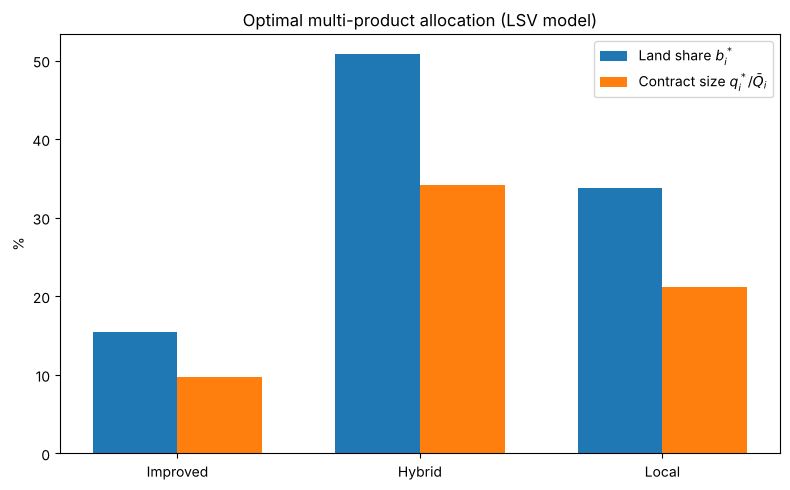

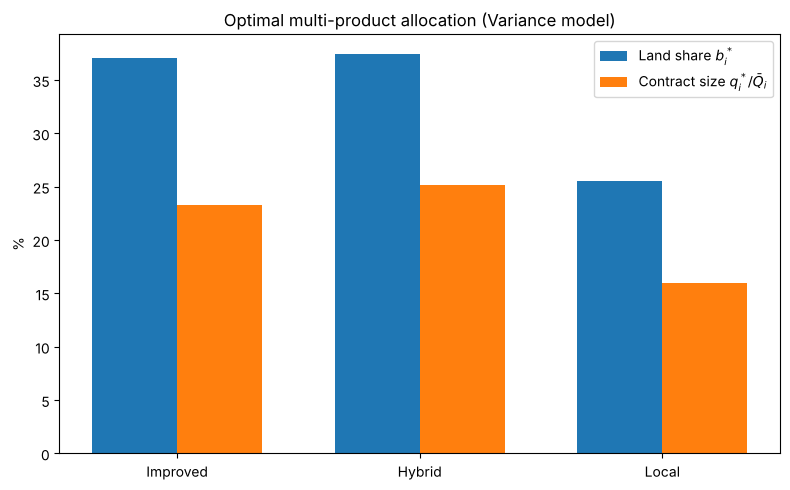

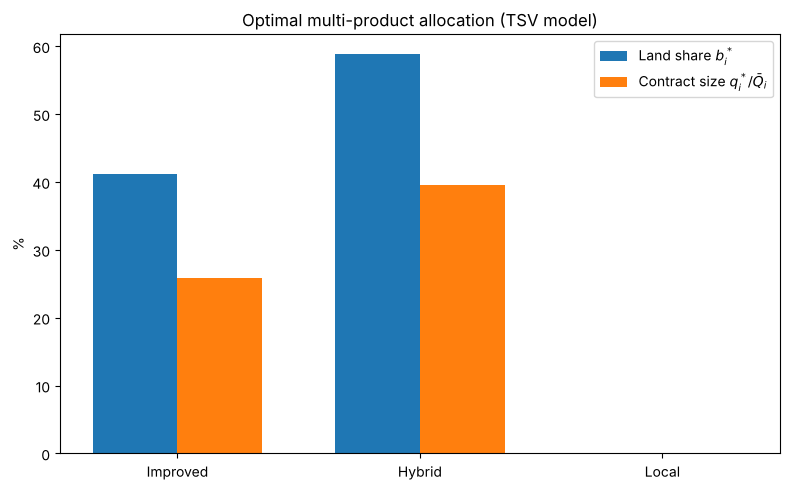

In [10]:
def plot_multi_product_allocation(b_vec, q_vec, Qbar_vec=None, crop_names=None, title="Optimal multi-product allocation"):
       """
       Plot land shares and contract shares for the multi-product model.

       Parameters
       ----------
       b_vec : array-like
              Optimal land shares b*.
       q_vec : array-like
              Optimal forward quantities q*.
       Qbar_vec : array-like, optional
              Expected yields per hectare E[Q_i]. If None, uses Q_mat.mean(axis=0).
       crop_names : list[str], optional
              Crop names for x-axis labels. If None, uses crop_names_multi.
       title : str, optional
              Plot title.
       """
       if Qbar_vec is None:
              Qbar_vec = Q_mat.mean(axis=0)

       if crop_names is None:
              crop_names = crop_names_multi

       b_vec = np.asarray(b_vec, dtype=float)
       q_vec = np.asarray(q_vec, dtype=float)
       Qbar_vec = np.asarray(Qbar_vec, dtype=float)

       contract_share = q_vec / Qbar_vec

       x = np.arange(len(crop_names))
       width = 0.35

       fig, ax = plt.subplots(figsize=(8, 5))
       ax.bar(x - width / 2, b_vec * 100, width, label="Land share $b_i^*$", color="tab:blue")
       ax.bar(
              x + width / 2,
              contract_share * 100,
              width,
              label="Contract size $q_i^* / \\bar{Q}_i$",
              color="tab:orange",
       )

       ax.set_ylabel("%")
       ax.set_xticks(x)
       ax.set_xticklabels(crop_names)
       ax.legend(loc="upper right")
       ax.set_title(title)
       plt.tight_layout()
       return fig, ax


# Plot LSV solution
fig_lsv, ax_lsv = plot_multi_product_allocation(
       b_star,
       q_star,
       crop_names=crop_names_multi,
       title="Optimal multi-product allocation (LSV model)",
)

# Plot variance solution
fig_var, ax_var = plot_multi_product_allocation(
       b_star_var,
       q_star_var,
       crop_names=crop_names_multi,
       title="Optimal multi-product allocation (Variance model)",
)

# Plot TSV solution
fig_tsv, ax_tsv = plot_multi_product_allocation(
       b_star_tsv,
       q_star_tsv,
       crop_names=crop_names_multi,
       title="Optimal multi-product allocation (TSV model)",
)

plt.show()

Sweeping m for Pareto fronts:   0%|          | 0/200 [00:00<?, ?m/s]

Sweeping m for Pareto fronts:   0%|          | 1/200 [00:00<02:40,  1.24m/s]

Sweeping m for Pareto fronts:   1%|          | 2/200 [00:01<02:23,  1.38m/s]

Sweeping m for Pareto fronts:   2%|▏         | 3/200 [00:02<02:19,  1.41m/s]

Sweeping m for Pareto fronts:   2%|▏         | 4/200 [00:02<02:21,  1.38m/s]

...

Sweeping m for Pareto fronts:  98%|█████████▊| 197/200 [01:26<00:01,  1.83m/s]

Sweeping m for Pareto fronts:  99%|█████████▉| 198/200 [01:26<00:01,  1.85m/s]

Sweeping m for Pareto fronts: 100%|█████████▉| 199/200 [01:27<00:00,  1.79m/s]

Sweeping m for Pareto fronts: 100%|██████████| 200/200 [01:28<00:00,  1.69m/s]

Sweeping m for Pareto fronts: 100%|██████████| 200/200 [01:28<00:00,  2.27m/s]

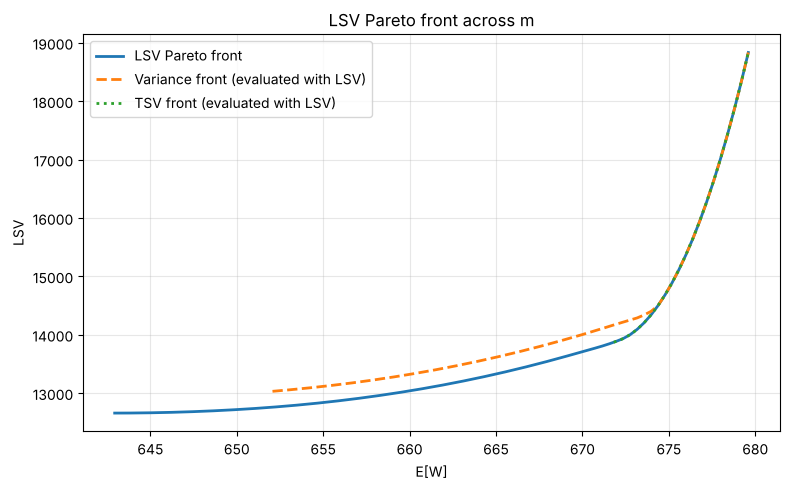

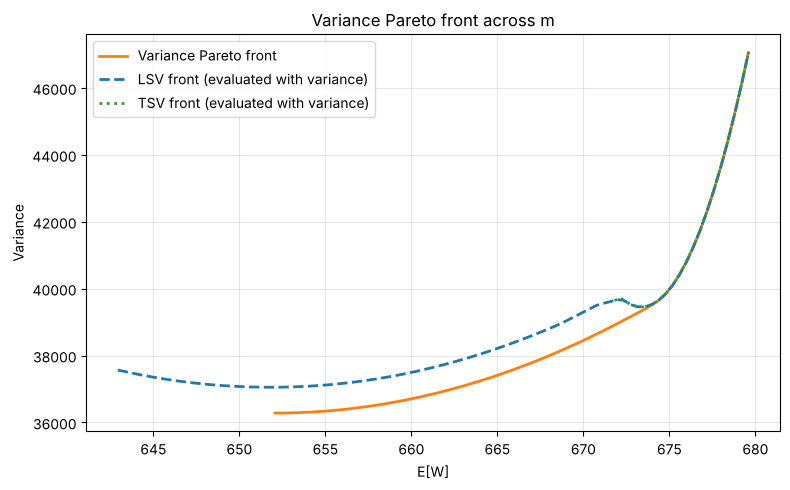

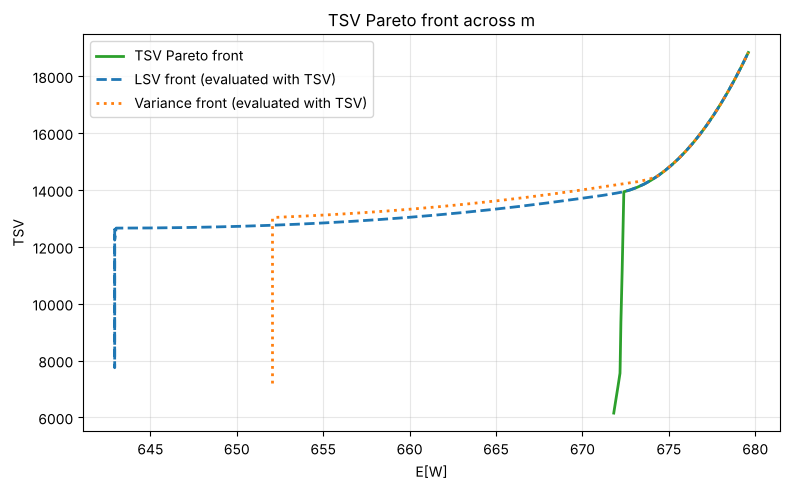

In [11]:
# Sweep m to build Pareto fronts for the LSV, variance, and TSV models
m_min = 600
m_max = 680
m_grid = np.linspace(m_min, m_max, 200)

lsv_front = []
var_front = []
tsv_front = []

for m in tqdm(m_grid, desc="Sweeping m for Pareto fronts", unit="m"):
    # LSV solve
    try:
        b_lsv, q_lsv, lsv_val, wbar_lsv = CVPI_optimization_multi(
            A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, float(m), verbose=False
        )
        lsv_front.append(
            (float(wbar_lsv), float(lsv_val), np.asarray(b_lsv, dtype=float), np.asarray(q_lsv, dtype=float), float(m))
        )
    except Exception:
        pass

    # Variance solve
    try:
        b_var, q_var, var_val, wbar_var = Variance_optimization_multi(
            Sigma, E_Y, float(m), r_vec, verbose=False
        )
        var_front.append(
            (float(wbar_var), float(var_val), np.asarray(b_var, dtype=float), np.asarray(q_var, dtype=float), float(m))
        )
    except Exception:
        pass

    # TSV solve
    try:
        b_tsv, q_tsv, tsv_val, wbar_tsv = CVPI_optimization_multi_TSV(
            A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, float(m), verbose=False
        )
        tsv_front.append(
            (float(wbar_tsv), float(tsv_val), np.asarray(b_tsv, dtype=float), np.asarray(q_tsv, dtype=float), float(m))
        )
    except Exception:
        pass

# Each front entry: (E[W], objective value, b, q, target m used in the solve).
# TSV is always evaluated against the point's own target m (m_pt).
# Sort by expected value for plotting
lsv_front = sorted(lsv_front, key=lambda item: item[0])
var_front = sorted(var_front, key=lambda item: item[0])
tsv_front = sorted(tsv_front, key=lambda item: item[0])

# Cross-evaluate each front under the other metrics
lsv_front_cross = []
for wbar, _, b, q, m_pt in var_front:
    v = np.concatenate([b, q])
    lsv_eval = LSV_multi(b, q, A_mat, C_mat)
    lsv_front_cross.append((wbar, float(lsv_eval)))

var_front_cross = []
for wbar, _, b, q, m_pt in lsv_front:
    v = np.concatenate([b, q])
    var_eval = float(v @ Sigma @ v)
    var_front_cross.append((wbar, var_eval))

tsv_front_cross = []
for wbar, _, b, q, m_pt in lsv_front:
    tsv_eval = TSV_multi(b, q, A_mat, C_mat, m_pt, PQbar_vec, Pbar_vec, f_vec)
    tsv_front_cross.append((wbar, float(tsv_eval)))

# Plot 1: LSV Pareto front
x_lsv = np.array([pt[0] for pt in lsv_front], dtype=float)
y_lsv = np.array([pt[1] for pt in lsv_front], dtype=float)

x_lsv_cross = np.array([pt[0] for pt in lsv_front_cross], dtype=float)
y_lsv_cross = np.array([pt[1] for pt in lsv_front_cross], dtype=float)

# Helper to evaluate any front under a specified metric
def evaluate_front(front, metric_name):
    xs = []
    ys = []
    for wbar, _, b, q, m_pt in front:
        b = np.asarray(b, dtype=float)
        q = np.asarray(q, dtype=float)
        v = np.concatenate([b, q])

        if metric_name == "LSV":
            y = float(LSV_multi(b, q, A_mat, C_mat))
        elif metric_name == "Var":
            y = float(v @ Sigma @ v)
        elif metric_name == "TSV":
            y = float(TSV_multi(b, q, A_mat, C_mat, m_pt, PQbar_vec, Pbar_vec, f_vec))
        else:
            raise ValueError(f"Unknown metric: {metric_name}")

        xs.append(float(wbar))
        ys.append(y)

    return np.asarray(xs, dtype=float), np.asarray(ys, dtype=float)

# Cross-evaluate all fronts under all metrics
x_lsv, y_lsv = evaluate_front(lsv_front, "LSV")
x_lsv_var_eval, y_lsv_var_eval = evaluate_front(var_front, "LSV")
x_lsv_tsv_eval, y_lsv_tsv_eval = evaluate_front(tsv_front, "LSV")

x_var, y_var = evaluate_front(var_front, "Var")
x_var_lsv_eval, y_var_lsv_eval = evaluate_front(lsv_front, "Var")
x_var_tsv_eval, y_var_tsv_eval = evaluate_front(tsv_front, "Var")

x_tsv, y_tsv = evaluate_front(tsv_front, "TSV")
x_tsv_lsv_eval, y_tsv_lsv_eval = evaluate_front(lsv_front, "TSV")
x_tsv_var_eval, y_tsv_var_eval = evaluate_front(var_front, "TSV")

# Plot 1: LSV metric
fig_lsv_front, ax_lsv_front = plt.subplots(figsize=(8, 5))
ax_lsv_front.plot(x_lsv, y_lsv, color="tab:blue", linewidth=2, label="LSV Pareto front")
ax_lsv_front.plot(x_lsv_var_eval, y_lsv_var_eval, color="tab:orange", linestyle="--", linewidth=2,
                 label="Variance front (evaluated with LSV)")
ax_lsv_front.plot(x_lsv_tsv_eval, y_lsv_tsv_eval, color="tab:green", linestyle=":", linewidth=2,
                 label="TSV front (evaluated with LSV)")
ax_lsv_front.set_xlabel("E[W]")
ax_lsv_front.set_ylabel("LSV")
ax_lsv_front.set_title("LSV Pareto front across m")
ax_lsv_front.grid(alpha=0.3)
ax_lsv_front.legend()
plt.tight_layout()

# Plot 2: Variance metric
fig_var_front, ax_var_front = plt.subplots(figsize=(8, 5))
ax_var_front.plot(x_var, y_var, color="tab:orange", linewidth=2, label="Variance Pareto front")
ax_var_front.plot(x_var_lsv_eval, y_var_lsv_eval, color="tab:blue", linestyle="--", linewidth=2,
                 label="LSV front (evaluated with variance)")
ax_var_front.plot(x_var_tsv_eval, y_var_tsv_eval, color="tab:green", linestyle=":", linewidth=2,
                 label="TSV front (evaluated with variance)")
ax_var_front.set_xlabel("E[W]")
ax_var_front.set_ylabel("Variance")
ax_var_front.set_title("Variance Pareto front across m")
ax_var_front.grid(alpha=0.3)
ax_var_front.legend()
plt.tight_layout()

# Plot 3: TSV metric
fig_tsv_front, ax_tsv_front = plt.subplots(figsize=(8, 5))
ax_tsv_front.plot(x_tsv, y_tsv, color="tab:green", linewidth=2, label="TSV Pareto front")
ax_tsv_front.plot(x_tsv_lsv_eval, y_tsv_lsv_eval, color="tab:blue", linestyle="--", linewidth=2,
                 label="LSV front (evaluated with TSV)")
ax_tsv_front.plot(x_tsv_var_eval, y_tsv_var_eval, color="tab:orange", linestyle=":", linewidth=2,
                 label="Variance front (evaluated with TSV)")
ax_tsv_front.set_xlabel("E[W]")
ax_tsv_front.set_ylabel("TSV")
ax_tsv_front.set_title("TSV Pareto front across m")
ax_tsv_front.grid(alpha=0.3)
ax_tsv_front.legend()
plt.tight_layout()

plt.show()

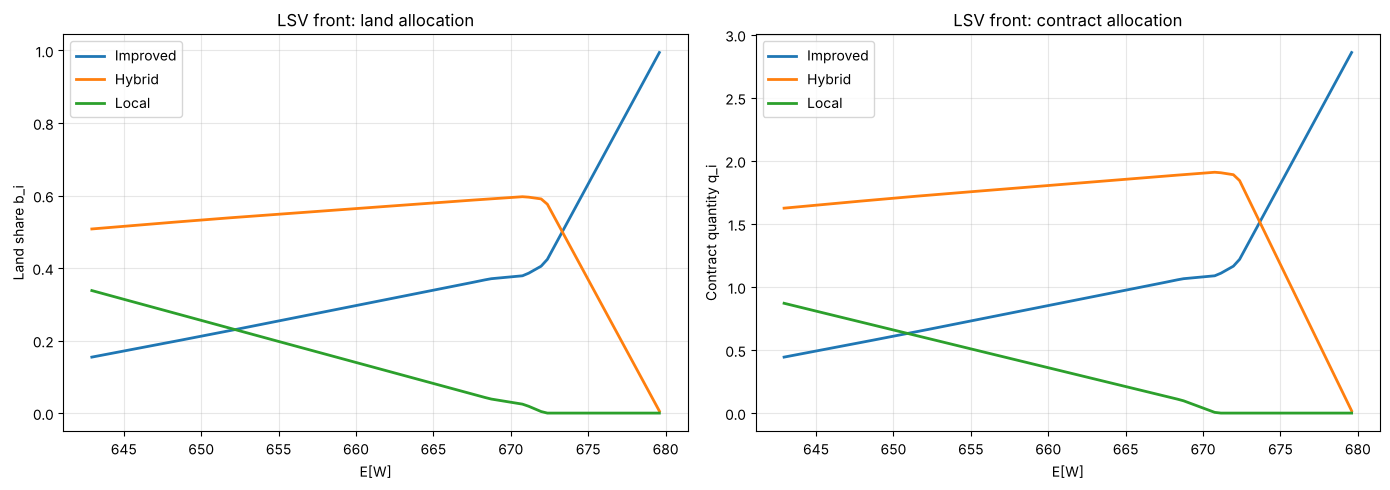

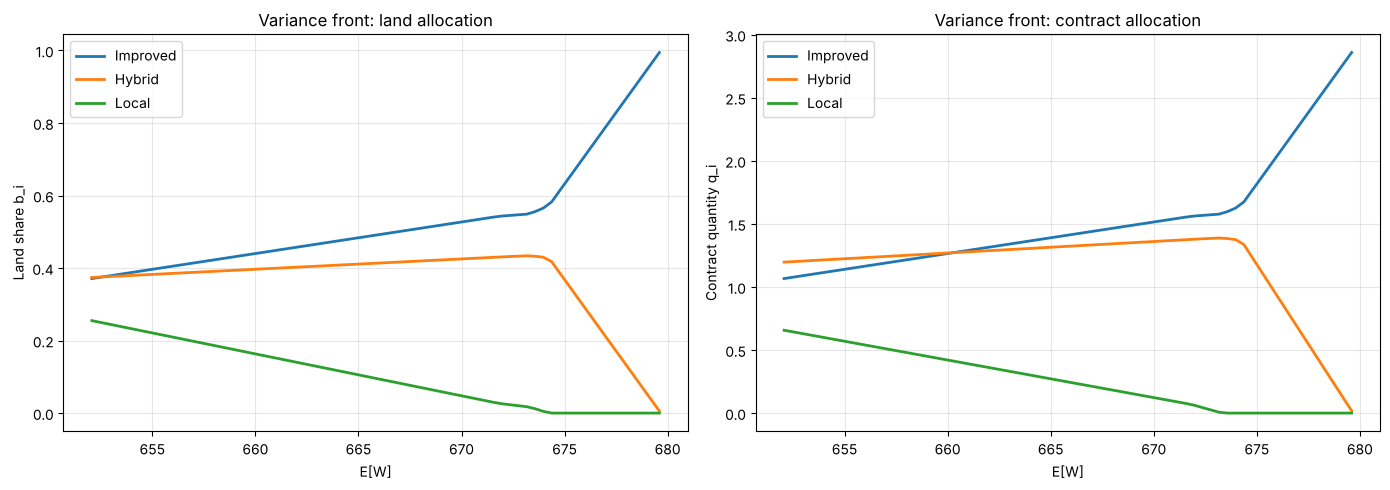

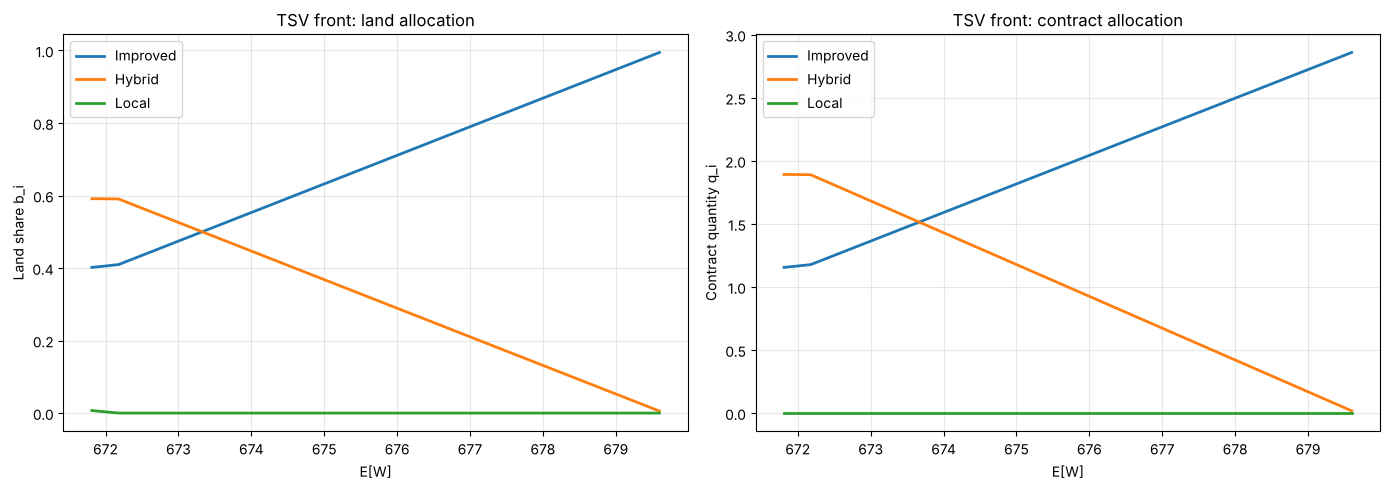

In [12]:
# Side-by-side land vs contract allocation plots for each front (LSV, variance, TSV)

fronts = {
    "LSV": lsv_front,
    "Variance": var_front,
    "TSV": tsv_front,
}

for metric_name, front in fronts.items():
    if not front:
        continue

    front = sorted(front, key=lambda item: item[0])  # sort by E[W]
    x = np.array([float(item[0]) for item in front], dtype=float)
    b_all = np.array([np.asarray(item[2], dtype=float) for item in front], dtype=float)
    q_all = np.array([np.asarray(item[3], dtype=float) for item in front], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    ax1, ax2 = axes

    # Left: land allocation
    for i, crop in enumerate(crop_names_multi):
        ax1.plot(x, b_all[:, i], linewidth=2, label=crop)
    ax1.set_xlabel("E[W]")
    ax1.set_ylabel("Land share b_i")
    ax1.set_title(f"{metric_name} front: land allocation")
    ax1.grid(alpha=0.3)
    ax1.legend(loc="best")

    # Right: contract allocation
    for i, crop in enumerate(crop_names_multi):
        ax2.plot(x, q_all[:, i], linewidth=2, label=crop)
    ax2.set_xlabel("E[W]")
    ax2.set_ylabel("Contract quantity q_i")
    ax2.set_title(f"{metric_name} front: contract allocation")
    ax2.grid(alpha=0.3)
    ax2.legend(loc="best")

    fig.tight_layout()
    plt.show()